In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
matches = pd.read_csv('../archive/matches.csv')
deliveries = pd.read_csv('../archive/deliveries.csv')

# Quick look
print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)
print("\n--- Columns in matches ---")
print(matches.columns.tolist())
print("\n--- First 3 rows ---")
print(matches.head(3))

Matches shape: (756, 18)
Deliveries shape: (179078, 21)

--- Columns in matches ---
['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2', 'umpire3']

--- First 3 rows ---
   id  season       city        date                team1  \
0   1    2017  Hyderabad  2017-04-05  Sunrisers Hyderabad   
1   2    2017       Pune  2017-04-06       Mumbai Indians   
2   3    2017     Rajkot  2017-04-07        Gujarat Lions   

                         team2                  toss_winner toss_decision  \
0  Royal Challengers Bangalore  Royal Challengers Bangalore         field   
1       Rising Pune Supergiant       Rising Pune Supergiant         field   
2        Kolkata Knight Riders        Kolkata Knight Riders         field   

   result  dl_applied                  winner  win_by_runs  win_by_wickets  \
0  normal           0     Sunrisers Hyderabad      

In [ ]:

print("--- Missing Values ---")
print(matches.isnull().sum())

print("\n--- Seasons available ---")
print(sorted(matches['season'].unique()))

print("\n--- Total teams ---")
print(matches['team1'].unique())

--- Missing Values ---
id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

--- Seasons available ---
[2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]

--- Total teams ---
['Sunrisers Hyderabad' 'Mumbai Indians' 'Gujarat Lions'
 'Rising Pune Supergiant' 'Royal Challengers Bangalore'
 'Kolkata Knight Riders' 'Delhi Daredevils' 'Kings XI Punjab'
 'Chennai Super Kings' 'Rajasthan Royals' 'Deccan Chargers'
 'Kochi Tuskers Kerala' 'Pune Warriors' 'Rising Pune Supergiants'
 'Delhi Capitals']


In [ ]:
#where winner is missing (tied matches)
matches_clean = matches.dropna(subset=['winner'])

print("Matches after cleaning:", matches_clean.shape)
print("Removed rows:", 756 - matches_clean.shape[0])

#no nulls in winner now
print("Nulls in winner:", matches_clean['winner'].isnull().sum())


Matches after cleaning: (752, 18)
Removed rows: 4
Nulls in winner: 0


C:\Users\jakku\AppData\Local\Temp\ipykernel_7528\283957323.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_wins.values, y=team_wins.index, palette='viridis')


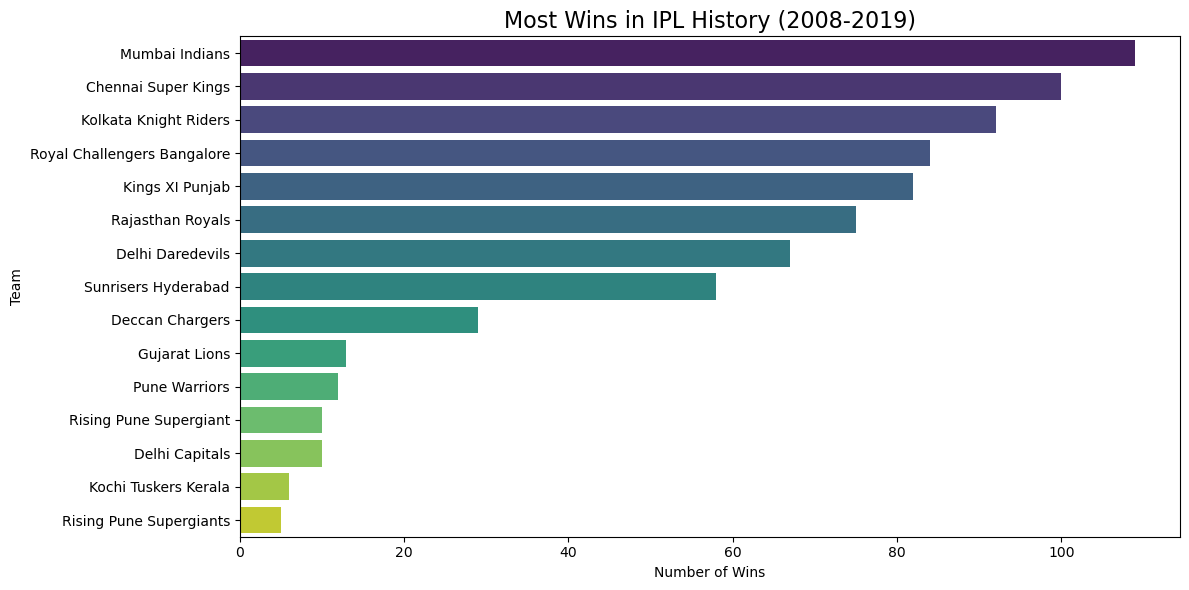


--- Top 5 Teams ---
winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Name: count, dtype: int64


In [4]:
# Which team has won the most matches?
team_wins = matches_clean['winner'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=team_wins.values, y=team_wins.index, palette='viridis')
plt.title('Most Wins in IPL History (2008-2019)', fontsize=16)
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.savefig('../team_wins.png')
plt.show()

print("\n--- Top 5 Teams ---")
print(team_wins.head())

C:\Users\jakku\AppData\Local\Temp\ipykernel_7528\735714586.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_clean['toss_match_winner'] = matches_clean['toss_winner'] == matches_clean['winner']


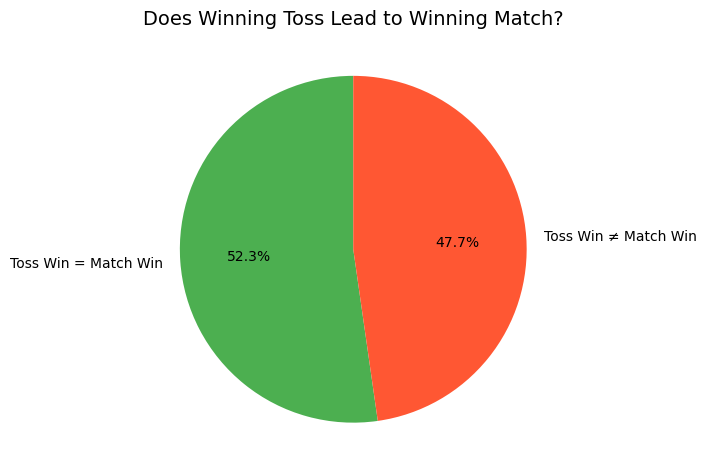


--- Toss Impact ---
toss_match_winner
True     393
False    359
Name: count, dtype: int64


In [5]:
# Did the toss winner also win the match?
matches_clean['toss_match_winner'] = matches_clean['toss_winner'] == matches_clean['winner']

toss_win_count = matches_clean['toss_match_winner'].value_counts()
labels = ['Toss Win = Match Win', 'Toss Win ≠ Match Win']

plt.figure(figsize=(7, 7))
plt.pie(toss_win_count.values, labels=labels, autopct='%1.1f%%', 
        colors=['#4CAF50', '#FF5733'], startangle=90)
plt.title('Does Winning Toss Lead to Winning Match?', fontsize=14)
plt.tight_layout()
plt.savefig('../toss_analysis.png')
plt.show()

print("\n--- Toss Impact ---")
print(toss_win_count)

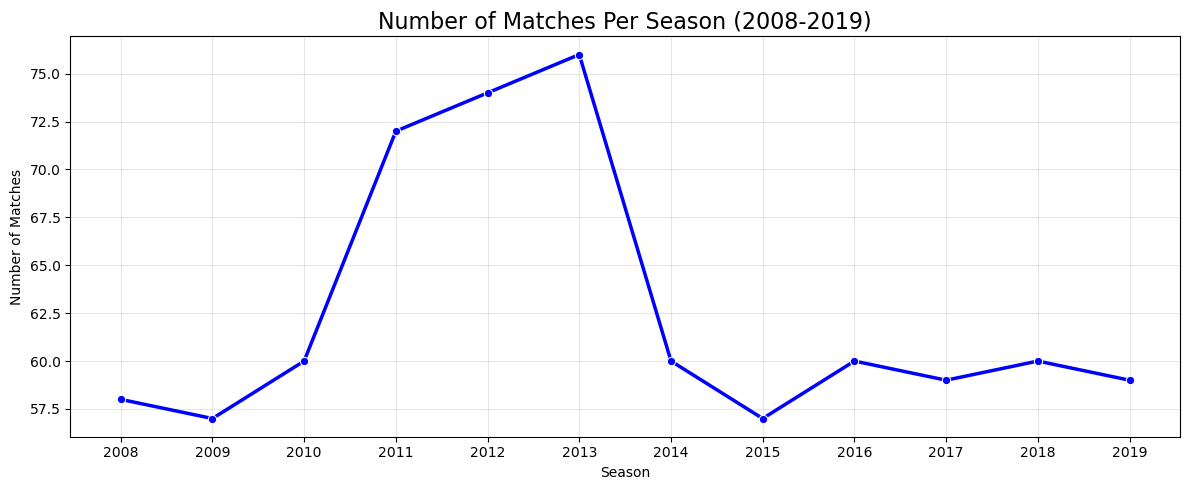


--- Matches per Season ---
season
2008    58
2009    57
2010    60
2011    72
2012    74
2013    76
2014    60
2015    57
2016    60
2017    59
2018    60
2019    59
Name: count, dtype: int64


In [6]:
# How many matches per season?
season_matches = matches_clean['season'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x=season_matches.index, y=season_matches.values, 
             marker='o', color='blue', linewidth=2.5)
plt.title('Number of Matches Per Season (2008-2019)', fontsize=16)
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(season_matches.index)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../season_matches.png')
plt.show()

print("\n--- Matches per Season ---")
print(season_matches)

C:\Users\jakku\AppData\Local\Temp\ipykernel_7528\3056923483.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_venues.values, y=top_venues.index, palette='magma')


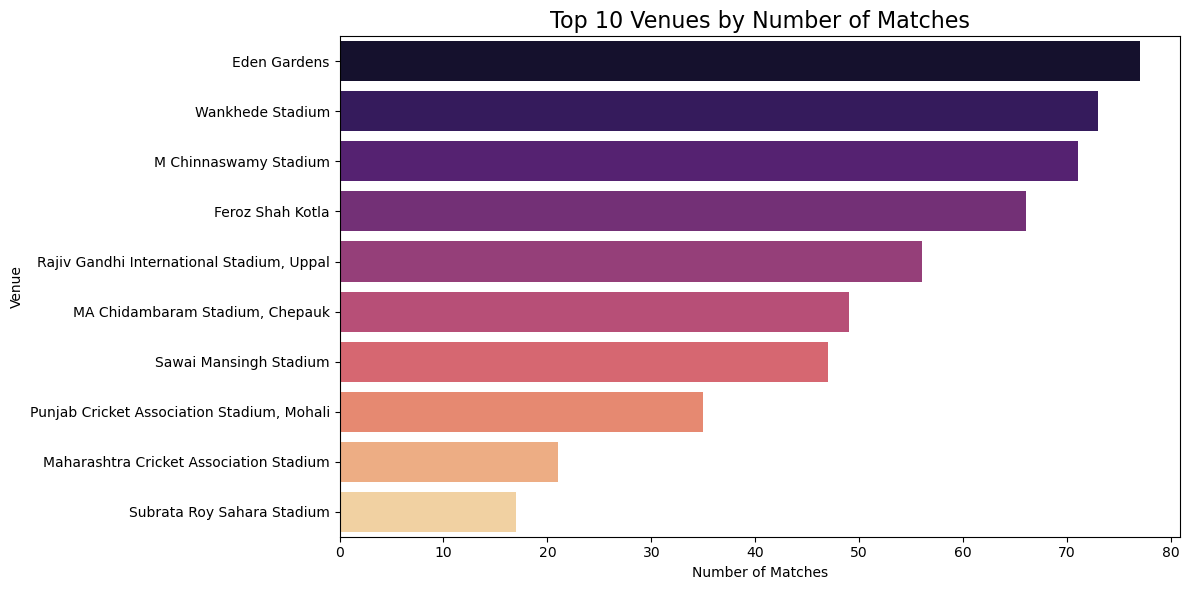


--- Top 5 Venues ---
venue
Eden Gardens                                 77
Wankhede Stadium                             73
M Chinnaswamy Stadium                        71
Feroz Shah Kotla                             66
Rajiv Gandhi International Stadium, Uppal    56
Name: count, dtype: int64


In [7]:
# Top 10 venues with most matches
top_venues = matches_clean['venue'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_venues.values, y=top_venues.index, palette='magma')
plt.title('Top 10 Venues by Number of Matches', fontsize=16)
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.tight_layout()
plt.savefig('../top_venues.png')
plt.show()

print("\n--- Top 5 Venues ---")
print(top_venues.head())

C:\Users\jakku\AppData\Local\Temp\ipykernel_7528\1964215844.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_players.values, y=top_players.index, palette='coolwarm')


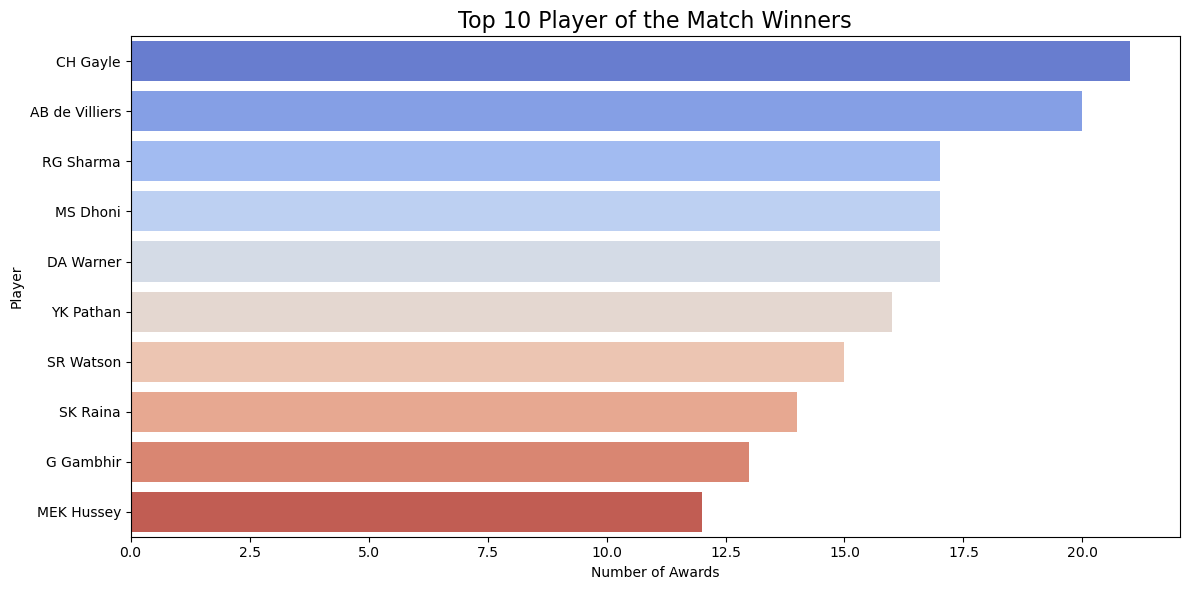


--- Top 5 Players ---
player_of_match
CH Gayle          21
AB de Villiers    20
RG Sharma         17
MS Dhoni          17
DA Warner         17
Name: count, dtype: int64


In [8]:
# Who won Player of the Match most times?
top_players = matches_clean['player_of_match'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_players.values, y=top_players.index, palette='coolwarm')
plt.title('Top 10 Player of the Match Winners', fontsize=16)
plt.xlabel('Number of Awards')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig('../top_players.png')
plt.show()

print("\n--- Top 5 Players ---")
print(top_players.head())

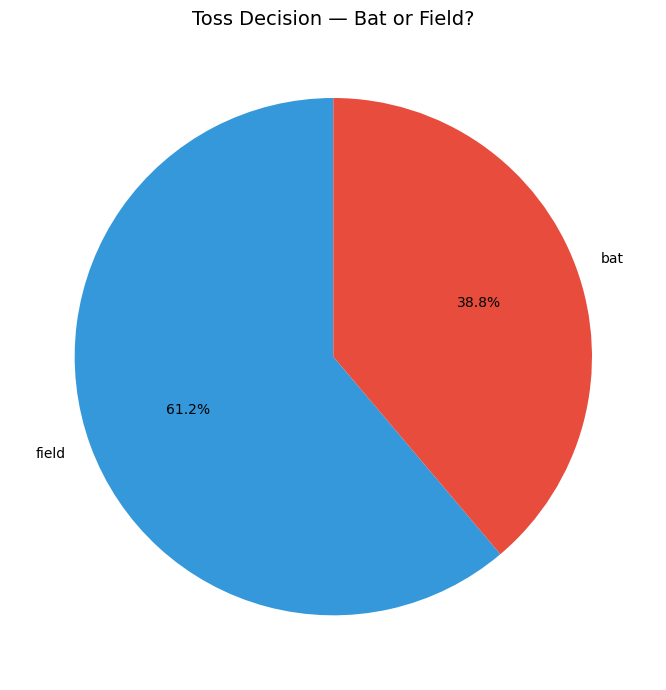


--- Toss Decision Count ---
toss_decision
field    460
bat      292
Name: count, dtype: int64


In [9]:
# Do teams prefer to bat or field after winning toss?
toss_decision = matches_clean['toss_decision'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(toss_decision.values, labels=toss_decision.index, autopct='%1.1f%%',
        colors=['#3498DB', '#E74C3C'], startangle=90)
plt.title('Toss Decision — Bat or Field?', fontsize=14)
plt.tight_layout()
plt.savefig('../toss_decision.png')
plt.show()

print("\n--- Toss Decision Count ---")
print(toss_decision)

In [10]:
print("=" * 50)
print("       IPL DATA ANALYSIS SUMMARY (2008-2019)")
print("=" * 50)

print(f"\n Total Matches Analyzed: {matches_clean.shape[0]}")
print(f" Seasons Covered: 2008 to 2019")

print(f"\n Most Successful Team: Mumbai Indians (109 wins)")
print(f" Runner Up: Chennai Super Kings (100 wins)")

print(f"\n Toss Impact: Toss winner wins only 52% of matches")
print(f" Toss Decision: 61% teams choose to field first")

print(f"\n Busiest Season: 2013 (76 matches)")
print(f" Most Used Venue: Eden Gardens (77 matches)")

print(f"\n Best Player of the Match: CH Gayle (21 awards)")
print(f" Second Best: AB de Villiers (20 awards)")

print("\n" + "=" * 50)
print("  Analysis Complete!")
print("=" * 50)

       IPL DATA ANALYSIS SUMMARY (2008-2019)

 Total Matches Analyzed: 752
 Seasons Covered: 2008 to 2019

 Most Successful Team: Mumbai Indians (109 wins)
 Runner Up: Chennai Super Kings (100 wins)

 Toss Impact: Toss winner wins only 52% of matches
 Toss Decision: 61% teams choose to field first

 Busiest Season: 2013 (76 matches)
 Most Used Venue: Eden Gardens (77 matches)

 Best Player of the Match: CH Gayle (21 awards)
 Second Best: AB de Villiers (20 awards)

  Analysis Complete!
